# Thesis Experiment: SAC & TD3 Gamma Controller (Weekly Rebalancing) + Explainability AI
**Setup:** 7-Day Rebalancing Frequency | SAC vs TD3 Comparison | Multi-seed evaluation | **XAI Added**

**Key Features:**
- `SAC` (Soft Actor-Critic) — off-policy, entropy regularization, stochastic policy
- `TD3` (Twin Delayed DDPG) — off-policy, deterministic policy, **[NEW] digunakan sebagai pembanding SAC**
- Includes `EquallyWeighted` & `ClassicalMarkowitz` as benchmarks
- Multi-seed training (3 seeds) for statistical credibility
- Reward normalization for training stability
- Added `Calmar Ratio` to evaluation metrics
- **Phase 11: Explainability AI** — SHAP, Sensitivity, Regime Correlation, Local Explanation

---
## 🆚 SAC vs TD3 — Perbedaan Teoritis

| Aspek | SAC | TD3 |
|-------|-----|-----|
| Policy type | Stochastic (Gaussian) | Deterministic |
| Entropy regularization | ✅ (`ent_coef='auto'`) | ❌ |
| Exploration | Via entropy term | Via action noise (Gaussian) |
| Twin critics | ✅ | ✅ |
| Delayed actor update | ❌ | ✅ (setiap 2 langkah) |
| Target policy noise | ❌ | ✅ (smoothing) |
| Sample efficiency | Tinggi | Tinggi |
| Tuning difficulty | Lebih mudah (entropy auto) | Butuh tuning action noise |

> **Hipotesis tesis**: SAC cenderung lebih eksploratorif dan robust di lingkungan dengan reward noise tinggi (pasar kripto), sedangkan TD3 bisa lebih stabil jika reward lebih deterministik.

# 📝 Experiment Improvement Plan & Thesis Notes

### 🔴 Critical Fixes Applied
1. **[FIX #1] Multi-Seed Statistical Credibility**: `SEEDS` diubah ke `[42, 123, 77]` — 3 seeds wajib untuk klaim statistik yang valid.
2. **[FIX #2] Training Steps**: `TRAIN_STEPS` = **50,000** untuk konvergensi yang memadai.
3. **[FIX #3] Welford M2 Init Bug**: `self._rew_M2` di `reset()` diperbaiki dari `1.0` → `0.0`.
4. **[FIX #4] Confidence Band OOS**: Percentile bootstrap (p5–p95) dari cumulative return tiap seed.
5. **[FIX #5] Action Space & Tanh Squashing**: SAC menggunakan tanh squashing internal; TD3 menggunakan action noise Gaussian.
6. **[FIX #6] Limitasi Transaction Cost**: Backtest mengabaikan biaya transaksi sebagai limitasi penelitian.

### 💡 TD3 Implementation Notes
- TD3 memerlukan `NormalActionNoise` untuk eksplorasi (karena policy-nya deterministik)
- `policy_delay=2` berarti actor diupdate setiap 2 critic updates
- `target_policy_noise` menambahkan noise ke target actions untuk smoothing Q-function
- File model TD3 disimpan terpisah dengan prefix `td3_`

In [1]:
%pip install stable_baselines3[extra] shap --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ================================================================
# GLOBAL EXPERIMENT SETTINGS
# ================================================================
SEEDS        = [42, 123, 77]   # [FIX #1] Wajib 3 seeds untuk tesis
TRAIN_STEPS  = 1000           # [FIX #2] Steps untuk konvergensi
GAMMA_CENTER = 1.0
GAMMA_RANGE  = 1.0
SET_WINDOW    = 30
SET_REBALANCE = 7
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces

# === Import SAC dan TD3 ===
from stable_baselines3 import SAC, TD3
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

from scipy.optimize import minimize
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded. SAC + TD3 comparison mode active.')
print(f'Settings Loaded: Seeds={SEEDS}, Steps={TRAIN_STEPS}, Gamma={GAMMA_CENTER}')

Libraries loaded. SAC + TD3 comparison mode active.
Settings Loaded: Seeds=[42, 123, 77], Steps=1000, Gamma=1.0


## Phase 1: Data Preparation

In [3]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]

    split_idx = int(len(df) * train_split)
    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]
    return train_df, test_df, assets

ret_old, ret_test, assets = load_and_split(file_data)

SET_WINDOW = 30
print(f'Data loaded. Assets ({len(assets)}): {assets}')
print(f'Training period : {ret_old.index[0].date()} – {ret_old.index[-1].date()} ({len(ret_old)} days)')
print(f'Test period (30%) : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Data loaded. Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training period : 2017-09-15 – 2019-03-02 (534 days)
Test period (30%) : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions

In [4]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def get_centrality_weights(returns_window, gamma=1.0):
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    bnds = tuple((0, 0.4) for _ in range(N))
    res  = minimize(fun, np.ones(N)/N, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x if res.success else np.ones(N)/N


def get_network_metrics(returns_window):
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
# 1. Network Density (standard undirected: ignore diagonal)
upper_idx = np.triu_indices(N, k=1)
density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32)


def calculate_metrics(returns_series):
    """Metrik performa portfolio — termasuk Calmar Ratio."""
    total_ret = (1 + returns_series).prod() - 1
    ann_ret   = (1 + total_ret) ** (252 / len(returns_series)) - 1
    ann_vol   = returns_series.std() * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0
    cumulative = (1 + returns_series).cumprod()
    peak       = cumulative.cummax()
    drawdown   = (cumulative - peak) / peak
    max_dd     = drawdown.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    return {
        'Total Return'   : total_ret,
        'Ann. Return'    : ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe Ratio'   : sharpe,
        'Calmar Ratio'   : calmar,
        'Max Drawdown'   : max_dd,
    }

print('Core functions defined.')

Core functions defined.


In [5]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()


class EquallyWeighted(PortfolioStrategy):
    """Benchmark 1: 1/N Equal Weight."""
    def compute_weights(self, rw):
        return np.ones(rw.shape[1]) / rw.shape[1]


class ClassicalMarkowitz(PortfolioStrategy):
    """Benchmark 2: Minimum Variance (no network regularization)."""
    def compute_weights(self, rw):
        cov = rw.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)


class NetworkMarkowitz(PortfolioStrategy):
    """NW baseline: fixed gamma."""
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, rw):
        return get_centrality_weights(rw, self.gamma)


class RLNetworkMarkowitz(PortfolioStrategy):
    """
    RL-based gamma controller — mendukung SAC dan TD3.

    [FIX #5] ACTION SPACE & SQUASHING:
    - SAC: tanh squashing internal pada actor network.
    - TD3: deterministic policy + Gaussian action noise saat training.
      Saat inference (deterministic=True), noise tidak ditambahkan.
    """
    def __init__(self, name, model_path, algo='SAC',
                 gamma_center=1.0, gamma_range=1.0):
        super().__init__(name)
        if algo == 'TD3':
            self.model = TD3.load(model_path)
        else:
            self.model = SAC.load(model_path)
        self.gamma_center = gamma_center
        self.gamma_range  = gamma_range

    def compute_weights(self, rw):
        nw_feat = get_network_metrics(rw)
        short_ret  = rw.iloc[-5:].mean().mean()
        long_ret   = rw.mean().mean()
        momentum   = short_ret - long_ret
        recent_vol = rw.iloc[-5:].std().mean()
        mkt_feat = np.array(
            [short_ret*100, momentum*100, recent_vol*100, 0.0],
            dtype=np.float32
        )
        obs = np.nan_to_num(np.concatenate([nw_feat, mkt_feat]))
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        return get_centrality_weights(rw, gamma=self.last_gamma)

print('Strategy classes defined (EquallyWeighted, ClassicalMarkowitz, NetworkMarkowitz, RLNetworkMarkowitz).')
print('RLNetworkMarkowitz sekarang mendukung algo="SAC" dan algo="TD3".')

Strategy classes defined (EquallyWeighted, ClassicalMarkowitz, NetworkMarkowitz, RLNetworkMarkowitz).
RLNetworkMarkowitz sekarang mendukung algo="SAC" dan algo="TD3".


## Phase 3: Environment & Precompute

**Setup Notes:**
- `action_space`: `[-5, 5]` — dipakai oleh SAC (tanh squashing) dan TD3 (action noise)
- `reward_normalization`: Welford running mean/std untuk stable scaling
- Reward modes: `'sharpe_incremental'` dan `'total_return'`

**[FIX #3] Welford M2 Bug:**
Fixed `_rew_M2 = 0.0` initialization in `reset()` untuk estimasi variance yang tidak bias.

In [6]:
def precompute_env_data(returns_data, window_size=30):
    n_steps = len(returns_data) - window_size
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    print(f'Precomputing {n_steps} window positions...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape
        nw_feat   = get_network_metrics(win)
        short_ret = win.iloc[-5:].mean().mean()
        long_ret  = win.mean().mean()
        mkt_feat  = np.array(
            [short_ret*100, (short_ret-long_ret)*100, win.iloc[-5:].std().mean()*100, 0.0],
            dtype=np.float32
        )
        obs_cache[i] = (nw_feat, mkt_feat)
        mu    = win.mean().values
        sigma = win.std().values
        corr_f = apply_rmt_filter(win)
        cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
        mst = nx.minimum_spanning_tree(nx.from_numpy_array(dist_mat))
        try:
            cent = nx.eigenvector_centrality(mst, max_iter=2000)
            cent_vec = np.array([cent[j] for j in range(N)])
        except:
            cent_vec = np.array(list(nx.degree_centrality(mst).values()))
        opt_cache[i] = (cov_f, cent_vec, mu)
        w_base = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)
    print(f'Precomputation done! ({n_steps} positions cached)')
    return obs_cache, opt_cache, baseline_ret_cache


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    N   = len(mu)
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    res = minimize(fun, np.ones(N)/N, method='SLSQP',
                   bounds=tuple((0, 0.4) for _ in range(N)), constraints=cons)
    return res.x if res.success else np.ones(N)/N

print('Precompute functions defined.')

Precompute functions defined.


In [7]:
class GammaPortfolioEnvFast(gym.Env):
    """
    Environment dengan gamma centering + reward normalization.
    Kompatibel dengan SAC dan TD3 (keduanya menggunakan continuous action space).

    Features:
    - Reward normalization (Welford running stats)
    - 'sharpe_incremental': reward = rolling_sharpe
    - 'total_return': reward = portfolio return
    - action_space [-5, 5]
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache=None, window_size=30,
                 reward_mode='excess_nw',
                 gamma_center=1.0, gamma_range=1.0,
                 normalize_reward=True):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache or {}
        self.window_size        = window_size
        self.reward_mode        = reward_mode
        self.gamma_center       = gamma_center
        self.gamma_range        = gamma_range
        self.normalize_reward   = normalize_reward
        self.current_step       = window_size
        self.port_val           = 1.0
        self.peak_val           = 1.0
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0   # [FIX #3] diperbaiki dari 1.0 → 0.0
        self._rew_count = 0
        self._ret_buffer = []
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)

    def _action_to_gamma(self, action):
        return float(np.clip(action, -5.0, 5.0)) + self.gamma_center

    def _get_obs(self):
        nw_feat, mkt_feat = self.obs_cache[self.current_step]
        mf = mkt_feat.copy()
        mf[3] = self.port_val - 1
        return np.concatenate([nw_feat, mf])

    def _normalize_reward(self, r):
        """Welford online normalization — unbiased running variance."""
        if not self.normalize_reward:
            return r
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return np.clip(r / std, -10.0, 10.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val     = 1.0
        self.peak_val     = 1.0
        self._ret_buffer  = []
        # [FIX #3] Reset Welford stats
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma    = self._action_to_gamma(action[0])
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w        = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)
        drawdown = (self.port_val - self.peak_val) / self.peak_val
        nw_ret   = self.baseline_ret_cache.get(self.current_step,
                        self.data.iloc[self.current_step].mean())
        self._ret_buffer.append(port_ret)
        if len(self._ret_buffer) > 20:
            self._ret_buffer.pop(0)

        if self.reward_mode == 'excess_nw':
            raw = (port_ret - nw_ret) * 100
        elif self.reward_mode == 'sharpe_incremental':
            if len(self._ret_buffer) >= 5:
                buf = np.array(self._ret_buffer)
                port_sharpe = buf.mean() / (buf.std() + 1e-8)
            else:
                port_sharpe = 0.0
            raw = port_sharpe * 10
        elif self.reward_mode == 'risk_adjusted_excess':
            excess     = (port_ret - nw_ret) * 100
            dd_penalty = min(abs(drawdown) * 10, 2.0)
            raw = excess - dd_penalty
        elif self.reward_mode == 'defensive':
            raw = (port_ret - 2.0 * abs(drawdown)) * 100
        else:
            raw = port_ret

        reward = self._normalize_reward(raw)

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)

        return obs, float(reward), done, False, {}

print('GammaPortfolioEnvFast defined (SAC + TD3 compatible).')

GammaPortfolioEnvFast defined (SAC + TD3 compatible).


In [8]:
# ================================================================
# Precompute Environment Data
# ================================================================
obs_cache, opt_cache, baseline_ret_cache = precompute_env_data(ret_old, window_size=SET_WINDOW)

Precomputing 504 window positions...
Precomputation done! (504 positions cached)


## Phase 4: Backtest Engine (Fixed Frequency Rebalancing)

In [9]:
def run_backtest_with_frequency(strategy, data, window=30, rebalance_freq=7):
    rets, dates, weights_history, gamma_history = [], [], [], []
    current_weights = None
    current_gamma   = 1.0
    print(f'Processing {strategy.name} (Freq: {rebalance_freq} days)...')
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df       = data.iloc[i-window:i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma   = getattr(strategy, 'last_gamma', 1.0)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            rets.append(daily_ret)
            dates.append(data.index[i])
            weights_history.append(current_weights)
            gamma_history.append(current_gamma)
    ret_series   = pd.Series(rets, index=dates, name=strategy.name)
    wts_df       = pd.DataFrame(weights_history, index=dates, columns=data.columns)
    gamma_series = pd.Series(gamma_history, index=dates, name=strategy.name)
    return ret_series, wts_df, gamma_series

print('Backtest engine defined.')

Backtest engine defined.


## Phase 5a: SAC Training (Multi-Seed)

**SAC Training Strategy:**
- **Off-policy** dengan replay buffer
- **Entropy coefficient**: `'auto'` (automatic tuning)
- **Batch size**: 256
- **Seeds**: 3 seeds untuk kredibilitas statistik

**[FIX #5] Tanh Squashing:**
SAC actor menggunakan tanh activation sebelum rescaling. Effective gamma ∈ (γ_center−5, γ_center+5) tapi tidak pernah menyentuh batas secara penuh.

In [10]:
# ================================================================
# SAC Hyperparameters
# ================================================================
sac_kwargs = {
    "policy": "MlpPolicy",
    "learning_rate": 3e-4,
    "buffer_size": 50000,
    "batch_size": 256,
    "ent_coef": "auto",
    "train_freq": 1,
    "gradient_steps": 1,
    "learning_starts": 1000,
    "tau": 0.005,
    "gamma": 0.99,
}
print('SAC kwargs ready.')

SAC kwargs ready.


In [11]:
reward_modes = {
    'sharpe_incremental': 'SAC-Net (Sharpe Incr)',
    'total_return'      : 'SAC-Net (Total Return)',
}

trained_sac_models = {}   # {(mode, seed): model_path}

for mode, label in reward_modes.items():
    for seed in SEEDS:
        model_name = f'sac_{mode}_seed{seed}'
        print(f'\nTraining [{label}] seed={seed}...')

        env = GammaPortfolioEnvFast(
            ret_old, obs_cache, opt_cache, baseline_ret_cache,
            window_size=SET_WINDOW, reward_mode=mode,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE,
            normalize_reward=True
        )

        model = SAC(env=env, seed=seed, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)

        trained_sac_models[(mode, seed)] = model_name
        print(f'  Saved: {model_name}.zip')

print('\n=== All SAC models trained ===')


Training [SAC-Net (Sharpe Incr)] seed=42...


Output()

Output()

  Saved: sac_sharpe_incremental_seed42.zip

Training [SAC-Net (Sharpe Incr)] seed=123...


Output()

...

Output()

  Saved: sac_total_return_seed42.zip

Training [SAC-Net (Total Return)] seed=123...


Output()

  Saved: sac_total_return_seed123.zip

Training [SAC-Net (Total Return)] seed=77...


  Saved: sac_total_return_seed77.zip

=== All SAC models trained ===


## Phase 5b: TD3 Training (Multi-Seed)

**TD3 Training Strategy:**
- **Off-policy** dengan replay buffer (sama seperti SAC)
- **Policy**: Deterministik (tidak ada entropy regularization)
- **Eksplorasi**: `NormalActionNoise` (σ = 0.1) ditambahkan ke action saat training
- **Delayed actor update**: Actor diupdate setiap `policy_delay=2` critic updates
- **Target policy smoothing**: Noise Gaussian pada target action untuk smooth Q-function

**Justifikasi hyperparameter TD3:**
- `noise_std=0.1`: Standar untuk continuous control tasks
- `policy_delay=2`: Default TD3 — mencegah actor update terlalu dini
- `target_policy_noise=0.2`: Smoothing regularizer pada target critic
- `target_noise_clip=0.5`: Batas clip untuk noise target

In [12]:
# ================================================================
# TD3 Hyperparameters
# ================================================================
# Action noise diperlukan untuk TD3 karena policy-nya deterministik.
# Tanpa noise, TD3 tidak akan mengeksplorasi action space saat training.
n_actions = 1  # gamma adalah scalar
action_noise = NormalActionNoise(
    mean=np.zeros(n_actions),
    sigma=0.1 * np.ones(n_actions)   # std = 0.1 dari range [-5, 5]
)

td3_kwargs = {
    "policy": "MlpPolicy",
    "learning_rate": 3e-4,
    "buffer_size": 50000,
    "batch_size": 256,
    "action_noise": action_noise,
    "train_freq": 1,
    "gradient_steps": 1,
    "learning_starts": 1000,
    "tau": 0.005,
    "gamma": 0.99,
    "policy_delay": 2,             # Actor update setiap 2 critic updates
    "target_policy_noise": 0.2,   # Noise pada target action untuk smoothing
    "target_noise_clip": 0.5,     # Batas clip noise target
}
print('TD3 kwargs ready.')
print(f'Action noise: NormalActionNoise(mean=0, sigma=0.1)')

TD3 kwargs ready.
Action noise: NormalActionNoise(mean=0, sigma=0.1)


In [13]:
# Reward modes yang sama dengan SAC untuk perbandingan fair
td3_reward_modes = {
    'sharpe_incremental': 'TD3-Net (Sharpe Incr)',
    'total_return'      : 'TD3-Net (Total Return)',
}

trained_td3_models = {}   # {(mode, seed): model_path}

for mode, label in td3_reward_modes.items():
    for seed in SEEDS:
        model_name = f'td3_{mode}_seed{seed}'
        print(f'\nTraining [{label}] seed={seed}...')

        env = GammaPortfolioEnvFast(
            ret_old, obs_cache, opt_cache, baseline_ret_cache,
            window_size=SET_WINDOW, reward_mode=mode,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE,
            normalize_reward=True
        )

        # Re-create action noise per training (agar state noise fresh)
        an = NormalActionNoise(
            mean=np.zeros(n_actions),
            sigma=0.1 * np.ones(n_actions)
        )

        model = TD3(env=env, seed=seed, **{**td3_kwargs, 'action_noise': an})
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)

        trained_td3_models[(mode, seed)] = model_name
        print(f'  Saved: {model_name}.zip')

print('\n=== All TD3 models trained ===')

Output()


Training [TD3-Net (Sharpe Incr)] seed=42...


Output()

  Saved: td3_sharpe_incremental_seed42.zip

Training [TD3-Net (Sharpe Incr)] seed=123...


Output()

...

Output()

  Saved: td3_total_return_seed42.zip

Training [TD3-Net (Total Return)] seed=123...


Output()

  Saved: td3_total_return_seed123.zip

Training [TD3-Net (Total Return)] seed=77...


  Saved: td3_total_return_seed77.zip

=== All TD3 models trained ===


## Phase 6: In-Sample Backtest (Training Data)

SAC dan TD3 dibacktest pada data training, kemudian diambil **mean ± confidence band** dari 3 seeds.

**[FIX #4]** Confidence band via **percentile bootstrap** (p5–p95, 90% CI).

In [14]:
COLORS = {
    'Equal Weight'            : 'dimgray',
    'Classical Markowitz'     : 'slategray',
    'NW (Gamma=1.0)'          : 'steelblue',
    'NW (Gamma=0.0)'          : 'lightblue',
    'SAC-Net (Sharpe Incr)'   : 'darkorange',
    'SAC-Net (Total Return)'  : 'purple',
    'TD3-Net (Sharpe Incr)'   : 'crimson',
    'TD3-Net (Total Return)'  : 'darkgreen',
    'BTC (Buy & Hold)'        : 'black',
}

def run_multiseed_backtest(mode, label, data, algo='SAC', seeds=SEEDS):
    """
    Jalankan backtest multi-seed untuk suatu mode dan algoritma.
    algo: 'SAC' atau 'TD3'
    """
    prefix = algo.lower()
    seed_results = {}
    for seed in seeds:
        model_path = f'{prefix}_{mode}_seed{seed}'
        strat = RLNetworkMarkowitz(
            f'{label} [s{seed}]', model_path, algo=algo,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE
        )
        ret, _, gamma = run_backtest_with_frequency(
            strat, data, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
        )
        seed_results[seed] = (ret, gamma)
    return seed_results


def aggregate_seed_results(seed_results):
    all_rets = pd.DataFrame({s: r for s, (r, _) in seed_results.items()})
    return all_rets.mean(axis=1), all_rets.std(axis=1)


def bootstrap_cumret_bands(seed_results, n_boot=1000, ci=90, random_state=42):
    """
    [FIX #4] Confidence band via percentile bootstrap (p5–p95).
    """
    rng = np.random.RandomState(random_state)
    seeds = list(seed_results.keys())
    all_cumrets = {s: (1 + seed_results[s][0]).cumprod() for s in seeds}
    cum_df   = pd.DataFrame(all_cumrets)
    cum_mean = cum_df.mean(axis=1)

    p_low  = (100 - ci) / 2
    p_high = 100 - p_low

    boot_means = []
    for _ in range(n_boot):
        sampled = rng.choice(seeds, size=len(seeds), replace=True)
        boot_cum = cum_df[sampled].values.mean(axis=1)
        boot_means.append(boot_cum)

    boot_arr = np.array(boot_means)
    lower_band = pd.Series(np.percentile(boot_arr, p_low,  axis=0), index=cum_mean.index)
    upper_band = pd.Series(np.percentile(boot_arr, p_high, axis=0), index=cum_mean.index)
    return cum_mean, lower_band, upper_band

print('Multi-seed backtest + bootstrap utilities defined.')
print('COLORS dict updated with TD3 entries (crimson, darkgreen).')

Multi-seed backtest + bootstrap utilities defined.
COLORS dict updated with TD3 entries (crimson, darkgreen).


In [15]:
# ── Baseline strategies ───────────────────────────────────────────────────
baseline_strategies = [
    EquallyWeighted('Equal Weight'),
    ClassicalMarkowitz('Classical Markowitz'),
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.0)', gamma=0.0),
]

results_train = {}
for s in baseline_strategies:
    ret, _, _ = run_backtest_with_frequency(
        s, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_train[s.name] = ret

# ── SAC in-sample ─────────────────────────────────────────────────────────
sac_seed_results_train = {}
for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_old, algo='SAC')
    sac_seed_results_train[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name = label
    results_train[label] = mean_ret

# ── TD3 in-sample ─────────────────────────────────────────────────────────
td3_seed_results_train = {}
for mode, label in td3_reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_old, algo='TD3')
    td3_seed_results_train[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name = label
    results_train[label] = mean_ret

print('In-sample backtest complete (SAC + TD3).')

Processing Equal Weight (Freq: 7 days)...
Processing Classical Markowitz (Freq: 7 days)...
Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s42] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s123] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s77] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s42] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s123] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s77] (Freq: 7 days)...
Processing TD3-Net (Sharpe Incr) [s42] (Freq: 7 days)...
Processing TD3-Net (Sharpe Incr) [s123] (Freq: 7 days)...
Processing TD3-Net (Sharpe Incr) [s77] (Freq: 7 days)...
Processing TD3-Net (Total Return) [s42] (Freq: 7 days)...
Processing TD3-Net (Total Return) [s123] (Freq: 7 days)...
Processing TD3-Net (Total Return) [s77] (Freq: 7 days)...
In-sample backtest complete (SAC + TD3).


## Phase 7: In-Sample Performance Metrics & Plots

In [16]:
os.makedirs('backtest_results', exist_ok=True)
csv_dir = 'backtest_results'

stats_train = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_train.items()}
).T
stats_train.index.name = 'Strategy'
stats_train.to_csv(os.path.join(csv_dir, 'sac_td3_train_metrics.csv'))

print('=== In-Sample Performance Metrics (Training) ===')
print(stats_train.round(4).to_string())

=== In-Sample Performance Metrics (Training) ===
                        Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown
Strategy                                                                                                    
Equal Weight                 -0.3509      -0.1944           0.8747       -0.2222       -0.2063       -0.9421
Classical Markowitz          -0.4094      -0.2315           0.8426       -0.2747       -0.2472       -0.9367
NW (Gamma=1.0)               -0.6291      -0.3910           0.8111       -0.4820       -0.4151       -0.9419
NW (Gamma=0.0)               -0.5232      -0.3095           0.7861       -0.3937       -0.3325       -0.9310
SAC-Net (Sharpe Incr)        -0.4374      -0.2499           0.8095       -0.3088       -0.2664       -0.9383
SAC-Net (Total Return)       -0.4374      -0.2499           0.8095       -0.3088       -0.2664       -0.9383
TD3-Net (Sharpe Incr)        -0.5584      -0.3355           0.8092       -0.414

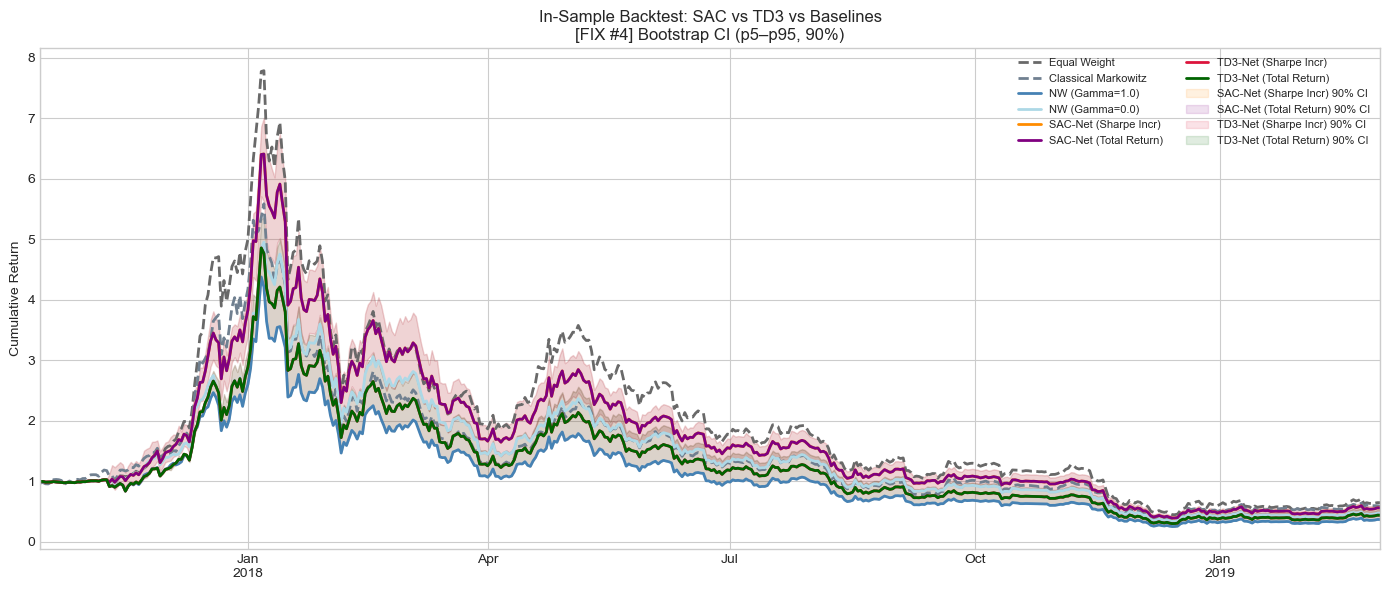

Saved: insample_cumret_sac_td3.png


In [17]:
# ── Plot: Cumulative Returns (Training) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for name, r in results_train.items():
    ls = '--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'gray'),
        linewidth=2.0, linestyle=ls
    )

# Bootstrap CI untuk SAC
for mode, label in reward_modes.items():
    sr = sac_seed_results_train[(mode, label)]
    cum_mean, lower_band, upper_band = bootstrap_cumret_bands(sr, n_boot=500, ci=90)
    ax.fill_between(cum_mean.index, lower_band, upper_band,
                    alpha=0.12, color=COLORS.get(label, 'orange'),
                    label=f'{label} 90% CI')

# Bootstrap CI untuk TD3
for mode, label in td3_reward_modes.items():
    sr = td3_seed_results_train[(mode, label)]
    cum_mean, lower_band, upper_band = bootstrap_cumret_bands(sr, n_boot=500, ci=90)
    ax.fill_between(cum_mean.index, lower_band, upper_band,
                    alpha=0.12, color=COLORS.get(label, 'red'),
                    label=f'{label} 90% CI')

ax.set_title('In-Sample Backtest: SAC vs TD3 vs Baselines\n[FIX #4] Bootstrap CI (p5–p95, 90%)')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(csv_dir, 'insample_cumret_sac_td3.png'), dpi=150)
plt.show()
print('Saved: insample_cumret_sac_td3.png')

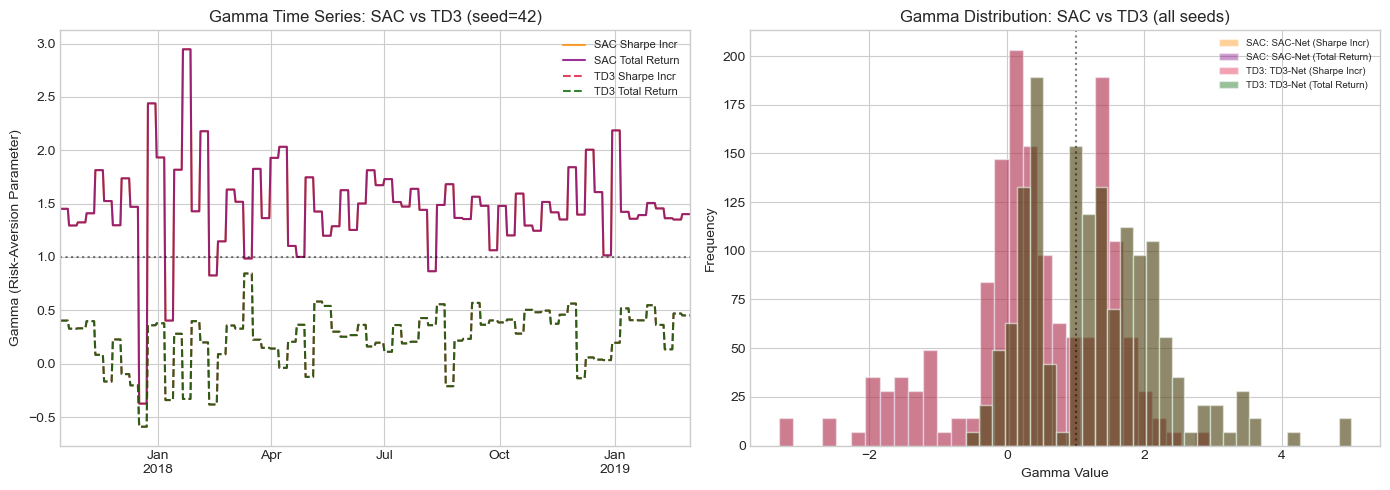

Saved: gamma_comparison_sac_td3.png


In [18]:
# ── Plot: Gamma Distribution Comparison (SAC vs TD3) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pilih seed pertama untuk visualisasi gamma
first_seed = SEEDS[0]

for mode, label in reward_modes.items():
    sr = sac_seed_results_train[(mode, label)]
    gamma_s = sr[first_seed][1]
    gamma_s.plot(ax=axes[0], label=f'SAC {label.split("(")[1][:-1]}',
                 color=COLORS.get(label, 'orange'), alpha=0.8)

for mode, label in td3_reward_modes.items():
    sr = td3_seed_results_train[(mode, label)]
    gamma_s = sr[first_seed][1]
    gamma_s.plot(ax=axes[0], label=f'TD3 {label.split("(")[1][:-1]}',
                 color=COLORS.get(label, 'crimson'), alpha=0.8, linestyle='--')

axes[0].set_title(f'Gamma Time Series: SAC vs TD3 (seed={first_seed})')
axes[0].set_ylabel('Gamma (Risk-Aversion Parameter)')
axes[0].legend(fontsize=8)
axes[0].axhline(y=GAMMA_CENTER, color='black', linestyle=':', alpha=0.5, label='Gamma Center')

# Histogram distribusi gamma
all_gammas = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_train[(mode, label)]
    gammas = np.concatenate([sr[s][1].values for s in SEEDS])
    all_gammas[f'SAC: {label}'] = gammas

for mode, label in td3_reward_modes.items():
    sr = td3_seed_results_train[(mode, label)]
    gammas = np.concatenate([sr[s][1].values for s in SEEDS])
    all_gammas[f'TD3: {label}'] = gammas

for name, g in all_gammas.items():
    algo = 'SAC' if 'SAC' in name else 'TD3'
    mode_key = 'Sharpe Incr' if 'Sharpe' in name else 'Total Return'
    label_key = f'{"SAC" if algo=="SAC" else "TD3"}-Net ({mode_key})'
    axes[1].hist(g, bins=30, alpha=0.4, label=name,
                 color=COLORS.get(label_key, 'gray'), edgecolor='white')

axes[1].set_title('Gamma Distribution: SAC vs TD3 (all seeds)')
axes[1].set_xlabel('Gamma Value')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=7)
axes[1].axvline(x=GAMMA_CENTER, color='black', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(csv_dir, 'gamma_comparison_sac_td3.png'), dpi=150)
plt.show()
print('Saved: gamma_comparison_sac_td3.png')

## Phase 8: Out-of-Sample Backtest (Validation Data 30%)

Evaluasi generalisasi model SAC dan TD3 pada data validasi (30%) yang tidak pernah dilihat saat training.

**[FIX #4]** Confidence band via percentile bootstrap (p5–p95, 90% CI).

**[FIX #6] Limitasi Transaction Cost:**
> ⚠️ Backtest ini **tidak memasukkan biaya transaksi**. Pada aset kripto dengan rebalancing mingguan, biaya ini bisa material (spread + taker fee ≈ 0.05–0.20% per transaksi). Ini adalah limitasi penelitian yang perlu dicantumkan di tesis.

In [19]:
# ── Baseline OOS ─────────────────────────────────────────────────────────
results_test = {}
for s in baseline_strategies:
    s2 = s.__class__(s.name, **({'gamma': s.gamma} if isinstance(s, NetworkMarkowitz) else {}))
    ret, _, _ = run_backtest_with_frequency(
        s2, ret_test, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_test[s.name] = ret

if 'BTC' in ret_test.columns:
    results_test['BTC (Buy & Hold)'] = ret_test['BTC'].iloc[SET_WINDOW:]

# ── SAC OOS ───────────────────────────────────────────────────────────────
sac_seed_results_test = {}
sac_gamma_test = {}
for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_test, algo='SAC')
    sac_seed_results_test[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name = label
    results_test[label] = mean_ret
    sac_gamma_test[label] = sr[SEEDS[0]][1]

# ── TD3 OOS ───────────────────────────────────────────────────────────────
td3_seed_results_test = {}
td3_gamma_test = {}
for mode, label in td3_reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_test, algo='TD3')
    td3_seed_results_test[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name = label
    results_test[label] = mean_ret
    td3_gamma_test[label] = sr[SEEDS[0]][1]

print('Out-of-sample backtest complete (SAC + TD3).')

Processing Equal Weight (Freq: 7 days)...
Processing Classical Markowitz (Freq: 7 days)...
Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s42] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s123] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s77] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s42] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s123] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s77] (Freq: 7 days)...
Processing TD3-Net (Sharpe Incr) [s42] (Freq: 7 days)...
Processing TD3-Net (Sharpe Incr) [s123] (Freq: 7 days)...
Processing TD3-Net (Sharpe Incr) [s77] (Freq: 7 days)...
Processing TD3-Net (Total Return) [s42] (Freq: 7 days)...
Processing TD3-Net (Total Return) [s123] (Freq: 7 days)...
Processing TD3-Net (Total Return) [s77] (Freq: 7 days)...
Out-of-sample backtest complete (SAC + TD3).


In [20]:
# ── Performance Metrics Table (Test Period) ───────────────────────────────
stats_test = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_test.items()}
).T
stats_test.index.name = 'Strategy'

# Sharpe std per seed untuk SAC
sharpe_std_test = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_test[(mode, label)]
    sharpe_per_seed = [calculate_metrics(r)['Sharpe Ratio'] for r, _ in sr.values()]
    sharpe_std_test[label] = np.std(sharpe_per_seed)

# Sharpe std per seed untuk TD3
for mode, label in td3_reward_modes.items():
    sr = td3_seed_results_test[(mode, label)]
    sharpe_per_seed = [calculate_metrics(r)['Sharpe Ratio'] for r, _ in sr.values()]
    sharpe_std_test[label] = np.std(sharpe_per_seed)

stats_test['Sharpe Std (seeds)'] = pd.Series(sharpe_std_test)
stats_test.to_csv(os.path.join(csv_dir, 'sac_td3_test_metrics.csv'))
pd.DataFrame({n: (1+r).cumprod() for n, r in results_test.items()}).to_csv(
    os.path.join(csv_dir, 'sac_td3_test_cumret.csv')
)

print('=== Out-of-Sample Performance Metrics (Validation) ===')
print(stats_test.round(4).to_string())
print('\n⚠️  [FIX #6] LIMITASI: Backtest tidak memasukkan transaction cost.')
print('   Untuk tesis: cantumkan asumsi zero transaction cost di Bab Metodologi.')

=== Out-of-Sample Performance Metrics (Validation) ===
                        Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown  Sharpe Std (seeds)
Strategy                                                                                                                        
Equal Weight                 -0.1844      -0.2275           0.6606       -0.3443       -0.3890       -0.5848                 NaN
Classical Markowitz          -0.1628      -0.2015           0.6321       -0.3188       -0.3722       -0.5414                 NaN
NW (Gamma=1.0)               -0.0791      -0.0991           0.6227       -0.1592       -0.1802       -0.5502                 NaN
NW (Gamma=0.0)               -0.0702      -0.0880           0.6216       -0.1416       -0.1580       -0.5571                 NaN
BTC (Buy & Hold)              0.6451       0.8783           0.6550        1.3410        1.9834       -0.4428                 NaN
SAC-Net (Sharpe Incr)        -0.0283      

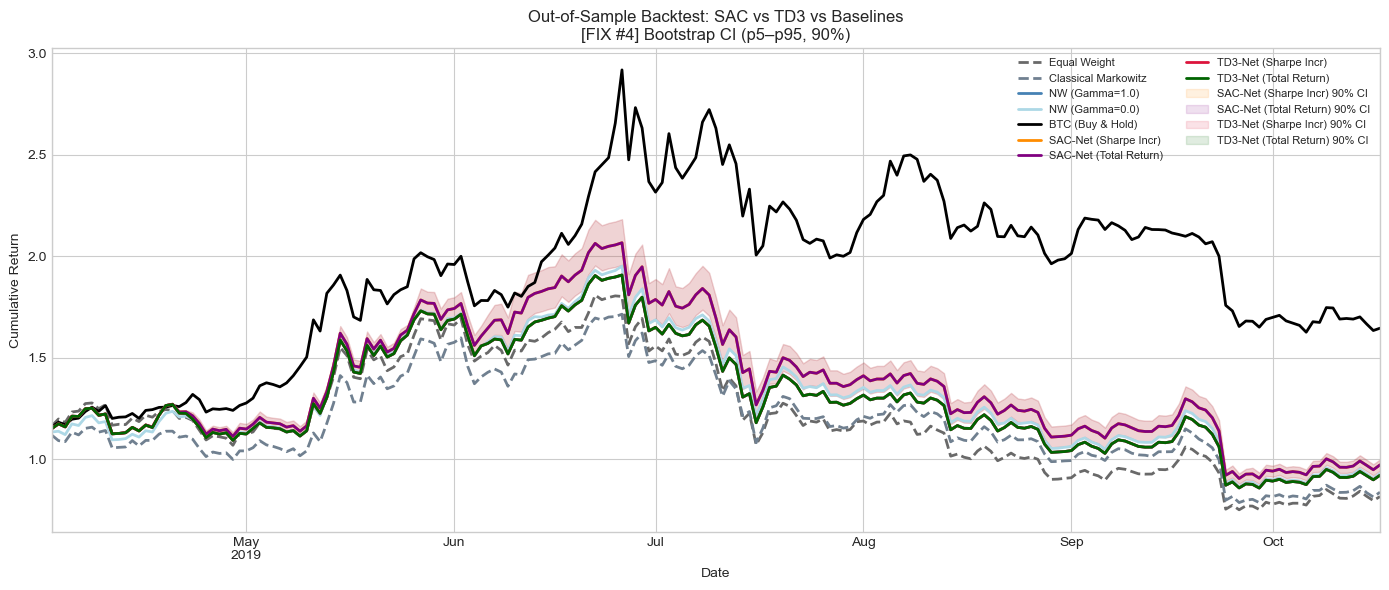

Saved: oos_cumret_sac_td3.png


In [21]:
# ── Plot: OOS Cumulative Returns ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for name, r in results_test.items():
    ls = '--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'gray'),
        linewidth=2.0, linestyle=ls
    )

# Bootstrap CI SAC
for mode, label in reward_modes.items():
    sr = sac_seed_results_test[(mode, label)]
    cum_mean, lower_band, upper_band = bootstrap_cumret_bands(sr, n_boot=500, ci=90)
    ax.fill_between(cum_mean.index, lower_band, upper_band,
                    alpha=0.12, color=COLORS.get(label, 'orange'),
                    label=f'{label} 90% CI')

# Bootstrap CI TD3
for mode, label in td3_reward_modes.items():
    sr = td3_seed_results_test[(mode, label)]
    cum_mean, lower_band, upper_band = bootstrap_cumret_bands(sr, n_boot=500, ci=90)
    ax.fill_between(cum_mean.index, lower_band, upper_band,
                    alpha=0.12, color=COLORS.get(label, 'red'),
                    label=f'{label} 90% CI')

ax.set_title('Out-of-Sample Backtest: SAC vs TD3 vs Baselines\n[FIX #4] Bootstrap CI (p5–p95, 90%)')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(csv_dir, 'oos_cumret_sac_td3.png'), dpi=150)
plt.show()
print('Saved: oos_cumret_sac_td3.png')

## Phase 9: SAC vs TD3 Head-to-Head Comparison

Analisis mendalam perbedaan perilaku SAC dan TD3 sebagai gamma controller.

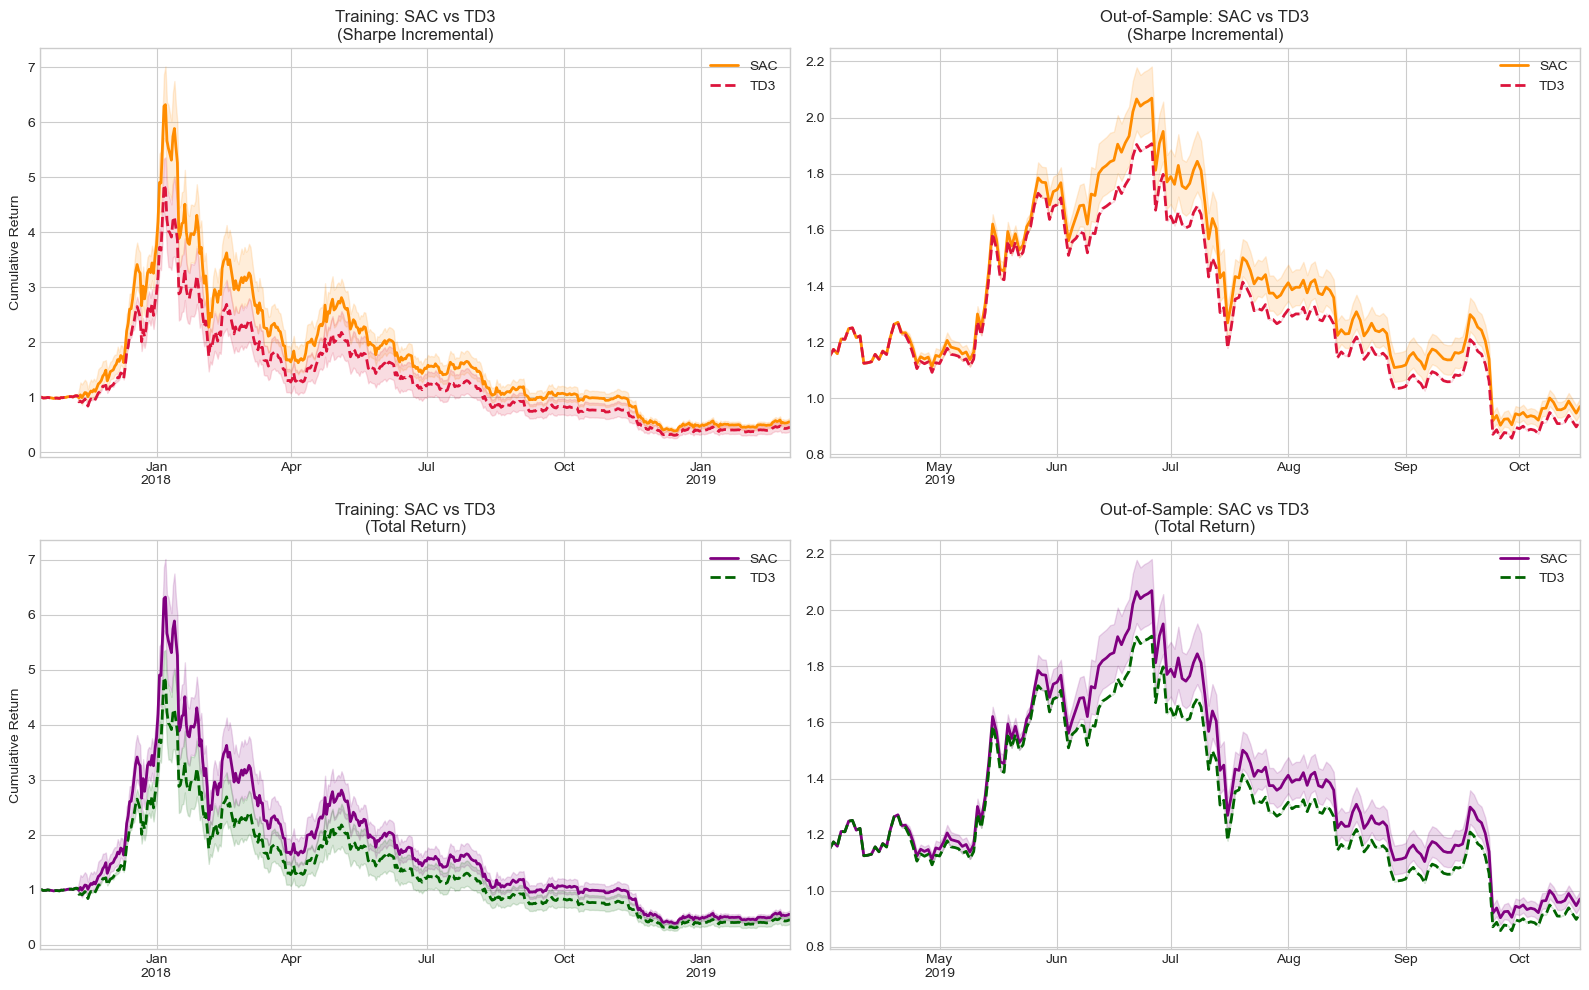

Saved: sac_td3_head2head.png


In [22]:
# ── Head-to-Head: SAC vs TD3 per reward mode ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

comparison_pairs = [
    ('sharpe_incremental', 'SAC-Net (Sharpe Incr)', 'TD3-Net (Sharpe Incr)'),
    ('total_return',       'SAC-Net (Total Return)', 'TD3-Net (Total Return)'),
]

for idx, (mode, sac_label, td3_label) in enumerate(comparison_pairs):
    ax_train = axes[idx * 2]
    ax_test  = axes[idx * 2 + 1]

    # Training
    sac_cum_train, sac_lo, sac_hi = bootstrap_cumret_bands(
        sac_seed_results_train[(mode, sac_label)], n_boot=300, ci=90)
    td3_cum_train, td3_lo, td3_hi = bootstrap_cumret_bands(
        td3_seed_results_train[(mode, td3_label)], n_boot=300, ci=90)

    sac_cum_train.plot(ax=ax_train, color=COLORS[sac_label], label='SAC', linewidth=2)
    ax_train.fill_between(sac_cum_train.index, sac_lo, sac_hi,
                          alpha=0.15, color=COLORS[sac_label])
    td3_cum_train.plot(ax=ax_train, color=COLORS[td3_label], label='TD3',
                       linewidth=2, linestyle='--')
    ax_train.fill_between(td3_cum_train.index, td3_lo, td3_hi,
                          alpha=0.15, color=COLORS[td3_label])
    ax_train.set_title(f'Training: SAC vs TD3\n({mode.replace("_", " ").title()})')
    ax_train.set_ylabel('Cumulative Return')
    ax_train.legend()

    # Test
    sac_cum_test, sac_lo_t, sac_hi_t = bootstrap_cumret_bands(
        sac_seed_results_test[(mode, sac_label)], n_boot=300, ci=90)
    td3_cum_test, td3_lo_t, td3_hi_t = bootstrap_cumret_bands(
        td3_seed_results_test[(mode, td3_label)], n_boot=300, ci=90)

    sac_cum_test.plot(ax=ax_test, color=COLORS[sac_label], label='SAC', linewidth=2)
    ax_test.fill_between(sac_cum_test.index, sac_lo_t, sac_hi_t,
                         alpha=0.15, color=COLORS[sac_label])
    td3_cum_test.plot(ax=ax_test, color=COLORS[td3_label], label='TD3',
                      linewidth=2, linestyle='--')
    ax_test.fill_between(td3_cum_test.index, td3_lo_t, td3_hi_t,
                         alpha=0.15, color=COLORS[td3_label])
    ax_test.set_title(f'Out-of-Sample: SAC vs TD3\n({mode.replace("_", " ").title()})')
    ax_test.legend()

plt.tight_layout()
plt.savefig(os.path.join(csv_dir, 'sac_td3_head2head.png'), dpi=150)
plt.show()
print('Saved: sac_td3_head2head.png')

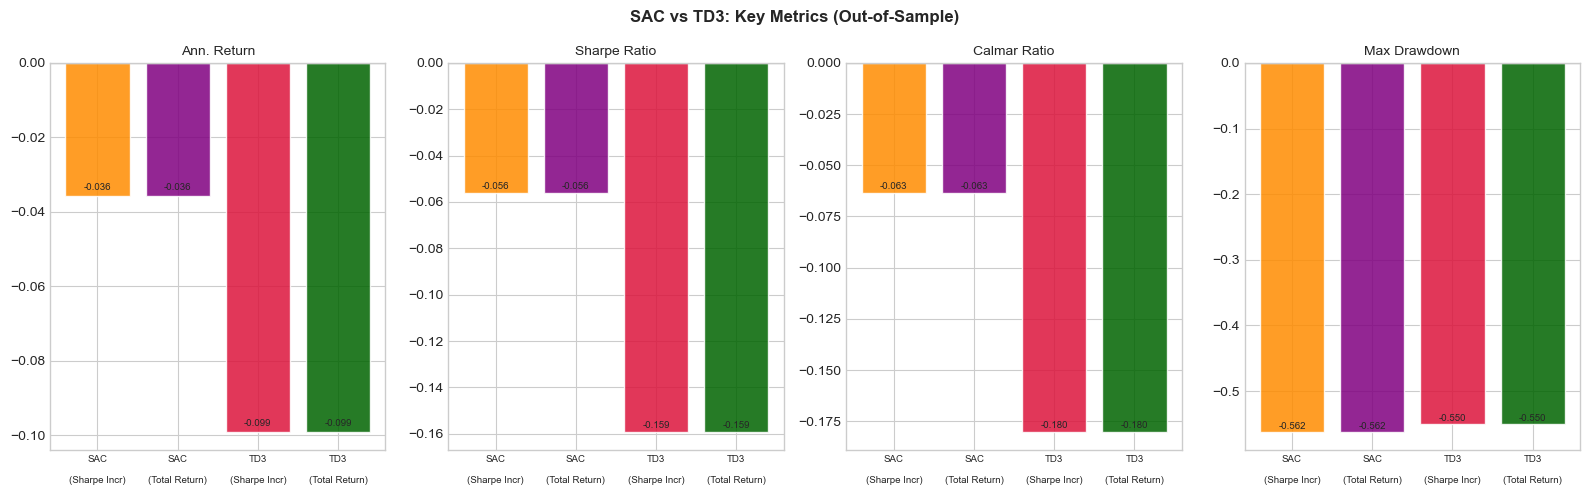

Saved: sac_td3_metrics_bar.png


In [23]:
# ── Bar chart: Key metrics comparison ────────────────────────────────────
rl_strategies = [
    'SAC-Net (Sharpe Incr)',
    'SAC-Net (Total Return)',
    'TD3-Net (Sharpe Incr)',
    'TD3-Net (Total Return)',
]
metrics_to_plot = ['Ann. Return', 'Sharpe Ratio', 'Calmar Ratio', 'Max Drawdown']
stats_rl = stats_test.loc[[s for s in rl_strategies if s in stats_test.index], metrics_to_plot]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors_bar = [
    COLORS['SAC-Net (Sharpe Incr)'],
    COLORS['SAC-Net (Total Return)'],
    COLORS['TD3-Net (Sharpe Incr)'],
    COLORS['TD3-Net (Total Return)'],
]

for i, metric in enumerate(metrics_to_plot):
    vals = stats_rl[metric]
    bars = axes[i].bar(range(len(vals)), vals.values, color=colors_bar[:len(vals)],
                       edgecolor='white', alpha=0.85)
    axes[i].set_title(metric, fontsize=10)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(
        [n.replace('-Net', '\n').replace(' (', '\n(') for n in vals.index],
        fontsize=7, rotation=0
    )
    axes[i].axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, vals.values):
        axes[i].text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7
        )

plt.suptitle('SAC vs TD3: Key Metrics (Out-of-Sample)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(csv_dir, 'sac_td3_metrics_bar.png'), dpi=150)
plt.show()
print('Saved: sac_td3_metrics_bar.png')

## Phase 10: Statistical Significance Tests (SAC vs TD3)

Uji signifikansi statistik menggunakan:
1. **Paired T-Test**: Membandingkan mean daily returns
2. **Diebold-Mariano (DM) Test**: Membandingkan akurasi prediktif dua time series returns

Fokus utama: apakah perbedaan SAC vs TD3 signifikan secara statistik?

In [24]:
def diebold_mariano_test(returns1, returns2, h=1):
    """
    Diebold-Mariano test dengan HAC variance estimator (Newey-West).
    """
    d = np.array(returns1) - np.array(returns2)
    T = float(len(d))
    d_bar = np.mean(d)

    def autocovariance(xi, k):
        N = len(xi)
        xs = xi - np.mean(xi)
        if k == 0:
            return np.sum(xs**2) / N
        return np.sum(xs[k:] * xs[:-k]) / N

    var_d_bar = autocovariance(d, 0)
    if h > 1:
        for lag in range(1, h):
            weight = 1.0 - lag / h
            var_d_bar += 2 * weight * autocovariance(d, lag)
    var_d_bar /= T

    if var_d_bar <= 0:
        return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(var_d_bar)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value


# ── Full significance test ────────────────────────────────────────────────
results_sig = []
target_strategies = list(results_test.keys())

print('Evaluating statistical significance on Out-of-Sample returns...')
for i in range(len(target_strategies)):
    for j in range(i + 1, len(target_strategies)):
        s1, s2 = target_strategies[i], target_strategies[j]
        if s1 in results_test and s2 in results_test:
            r1, r2 = results_test[s1], results_test[s2]
            min_len = min(len(r1), len(r2))
            r1, r2 = r1.iloc[:min_len], r2.iloc[:min_len]

            t_stat, t_p   = stats.ttest_rel(r1, r2)
            dm_stat, dm_p = diebold_mariano_test(r1, r2, h=1)

            results_sig.append({
                'Comparison'  : f'{s1} vs {s2}',
                'T-Stat'      : round(t_stat, 4),
                'T p-value'   : round(t_p, 4),
                'DM-Stat'     : round(dm_stat, 4),
                'DM p-value'  : round(dm_p, 4),
                'Significant' : 'Yes*' if dm_p < 0.05 else 'No'
            })

df_sig = pd.DataFrame(results_sig)

# Highlight SAC vs TD3 comparisons
print('\n=== SAC vs TD3 Direct Comparison (DM Test) ===')
sac_td3_mask = df_sig['Comparison'].str.contains('SAC') & df_sig['Comparison'].str.contains('TD3')
print(df_sig[sac_td3_mask].to_string(index=False))

print('\n=== Full Diebold-Mariano Test Results (OOS) ===')
print(df_sig.to_string(index=False))

df_sig.to_csv(os.path.join(csv_dir, 'statistical_significance_sac_td3.csv'), index=False)
print(f'\nSaved: {csv_dir}/statistical_significance_sac_td3.csv')
print('* Significant at α=0.05 (two-sided DM test)')

Evaluating statistical significance on Out-of-Sample returns...

=== SAC vs TD3 Direct Comparison (DM Test) ===
                                      Comparison  T-Stat  T p-value  DM-Stat  DM p-value Significant
  SAC-Net (Sharpe Incr) vs TD3-Net (Sharpe Incr)  1.2331      0.219   1.2362      0.2164          No
 SAC-Net (Sharpe Incr) vs TD3-Net (Total Return)  1.2331      0.219   1.2362      0.2164          No
 SAC-Net (Total Return) vs TD3-Net (Sharpe Incr)  1.2331      0.219   1.2362      0.2164          No
SAC-Net (Total Return) vs TD3-Net (Total Return)  1.2331      0.219   1.2362      0.2164          No

=== Full Diebold-Mariano Test Results (OOS) ===
                                      Comparison  T-Stat  T p-value  DM-Stat  DM p-value Significant
             Equal Weight vs Classical Markowitz -0.0942     0.9250  -0.0944      0.9248          No
                  Equal Weight vs NW (Gamma=1.0) -0.8442     0.3996  -0.8463      0.3974          No
                  Equal Weight 

## Phase 11: Explainability AI (XAI) — Interpretasi Model SAC

Fase ini menambahkan **Explainability AI** untuk menjawab pertanyaan:
> *"Mengapa SAC/TD3 memilih nilai gamma tertentu pada kondisi pasar tertentu?"*

| # | Teknik | Scope | Pertanyaan yang dijawab |
|---|--------|-------|------------------------|
| 11.1 | **SHAP KernelExplainer** | Global + Local | Fitur mana yang paling mempengaruhi gamma? |
| 11.2 | **Feature Sensitivity Analysis** | Global | Seberapa besar perubahan gamma jika satu fitur diubah? |
| 11.3 | **Gamma–Market Regime Correlation** | Global | Apakah model adaptif terhadap kondisi pasar? |
| 11.4 | **SAC vs TD3 SHAP Comparison** | Global | Apakah SAC dan TD3 fokus pada fitur yang sama? |

In [25]:
import shap
warnings.filterwarnings('ignore')

FEATURE_NAMES = [
    'Centrality Std×10',
    'Centrality Mean×10',
    'MST Distance×0.1',
    'Max Centrality',
    'Correlation Density',
    'Short-term Return×100',
    'Momentum×100',
    'Recent Volatility×100',
    'Portfolio Value-1',
]

def collect_observations(data, obs_cache, window_size=30, max_obs=200):
    """
    Kumpulkan observasi dari obs_cache untuk analisis XAI.
    Dibatasi max_obs untuk efisiensi komputasi.
    """
    obs_list = []
    indices = sorted(obs_cache.keys())
    step = max(1, len(indices) // max_obs)
    for i in indices[::step][:max_obs]:
        nw_feat, mkt_feat = obs_cache[i]
        mf = mkt_feat.copy()
        mf[3] = 0.0
        obs_list.append(np.concatenate([nw_feat, mf]))
    return np.array(obs_list, dtype=np.float32)

# Load model SAC dan TD3 terbaik untuk XAI (gunakan seed pertama)
xai_sac_model = SAC.load(f'sac_sharpe_incremental_seed{SEEDS[0]}')
xai_td3_model = TD3.load(f'td3_sharpe_incremental_seed{SEEDS[0]}')

xai_obs = collect_observations(ret_old, obs_cache, window_size=SET_WINDOW, max_obs=200)
bg_obs  = xai_obs[:50]   # background dataset untuk SHAP

print('XAI setup complete.')
print(f'Observations collected: {len(xai_obs)}')
print(f'Feature names ({len(FEATURE_NAMES)}):')
for i, f in enumerate(FEATURE_NAMES):
    print(f'  [{i}] {f}')

XAI setup complete.
Observations collected: 200
Feature names (9):
  [0] Centrality Std×10
  [1] Centrality Mean×10
  [2] MST Distance×0.1
  [3] Max Centrality
  [4] Correlation Density
  [5] Short-term Return×100
  [6] Momentum×100
  [7] Recent Volatility×100
  [8] Portfolio Value-1


In [26]:
# ── SHAP Global Importance: SAC ───────────────────────────────────────────
def sac_predict_fn(obs_array):
    actions = []
    for obs in obs_array:
        a, _ = xai_sac_model.predict(obs.astype(np.float32), deterministic=True)
        actions.append(float(a[0]))
    return np.array(actions)

def td3_predict_fn(obs_array):
    actions = []
    for obs in obs_array:
        a, _ = xai_td3_model.predict(obs.astype(np.float32), deterministic=True)
        actions.append(float(a[0]))
    return np.array(actions)

print('Computing SHAP values for SAC...')
explainer_sac = shap.KernelExplainer(sac_predict_fn, bg_obs)
shap_vals_sac = explainer_sac.shap_values(xai_obs[:100], nsamples=100)

print('Computing SHAP values for TD3...')
explainer_td3 = shap.KernelExplainer(td3_predict_fn, bg_obs)
shap_vals_td3 = explainer_td3.shap_values(xai_obs[:100], nsamples=100)

print('SHAP computation complete.')

Computing SHAP values for SAC...


  0%|          | 0/100 [00:00<?, ?it/s]

Computing SHAP values for TD3...


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP computation complete.


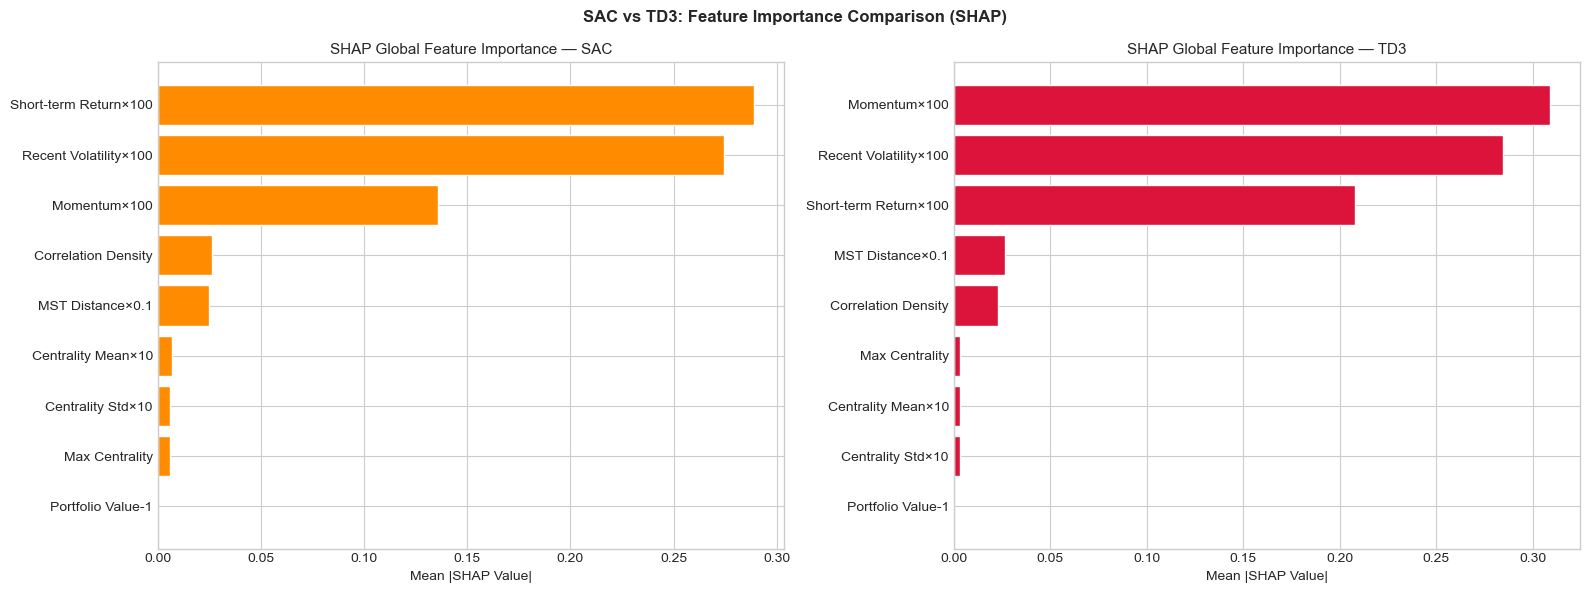


=== Top Features: SAC ===
  1. Short-term Return×100: 0.289048
  2. Recent Volatility×100: 0.274397
  3. Momentum×100: 0.135848
  4. Correlation Density: 0.026403
  5. MST Distance×0.1: 0.024899

=== Top Features: TD3 ===
  1. Momentum×100: 0.308900
  2. Recent Volatility×100: 0.284463
  3. Short-term Return×100: 0.207820
  4. MST Distance×0.1: 0.026688
  5. Correlation Density: 0.023221
Saved: xai_shap_sac_vs_td3.png


In [27]:
# ── SHAP Importance Comparison: SAC vs TD3 ────────────────────────────────
mean_abs_sac = np.abs(shap_vals_sac).mean(axis=0)
mean_abs_td3 = np.abs(shap_vals_td3).mean(axis=0)

sorted_idx_sac = np.argsort(mean_abs_sac)[::-1]
sorted_idx_td3 = np.argsort(mean_abs_td3)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SAC
axes[0].barh(
    [FEATURE_NAMES[i][:25] for i in sorted_idx_sac],
    mean_abs_sac[sorted_idx_sac],
    color=COLORS['SAC-Net (Sharpe Incr)'], edgecolor='white'
)
axes[0].set_title('SHAP Global Feature Importance — SAC', fontsize=11)
axes[0].set_xlabel('Mean |SHAP Value|')
axes[0].invert_yaxis()

# TD3
axes[1].barh(
    [FEATURE_NAMES[i][:25] for i in sorted_idx_td3],
    mean_abs_td3[sorted_idx_td3],
    color=COLORS['TD3-Net (Sharpe Incr)'], edgecolor='white'
)
axes[1].set_title('SHAP Global Feature Importance — TD3', fontsize=11)
axes[1].set_xlabel('Mean |SHAP Value|')
axes[1].invert_yaxis()

plt.suptitle('SAC vs TD3: Feature Importance Comparison (SHAP)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(csv_dir, 'xai_shap_sac_vs_td3.png'), dpi=150)
plt.show()

print('\n=== Top Features: SAC ===')
for rank, i in enumerate(sorted_idx_sac[:5], 1):
    print(f'  {rank}. {FEATURE_NAMES[i]}: {mean_abs_sac[i]:.6f}')

print('\n=== Top Features: TD3 ===')
for rank, i in enumerate(sorted_idx_td3[:5], 1):
    print(f'  {rank}. {FEATURE_NAMES[i]}: {mean_abs_td3[i]:.6f}')

print('Saved: xai_shap_sac_vs_td3.png')

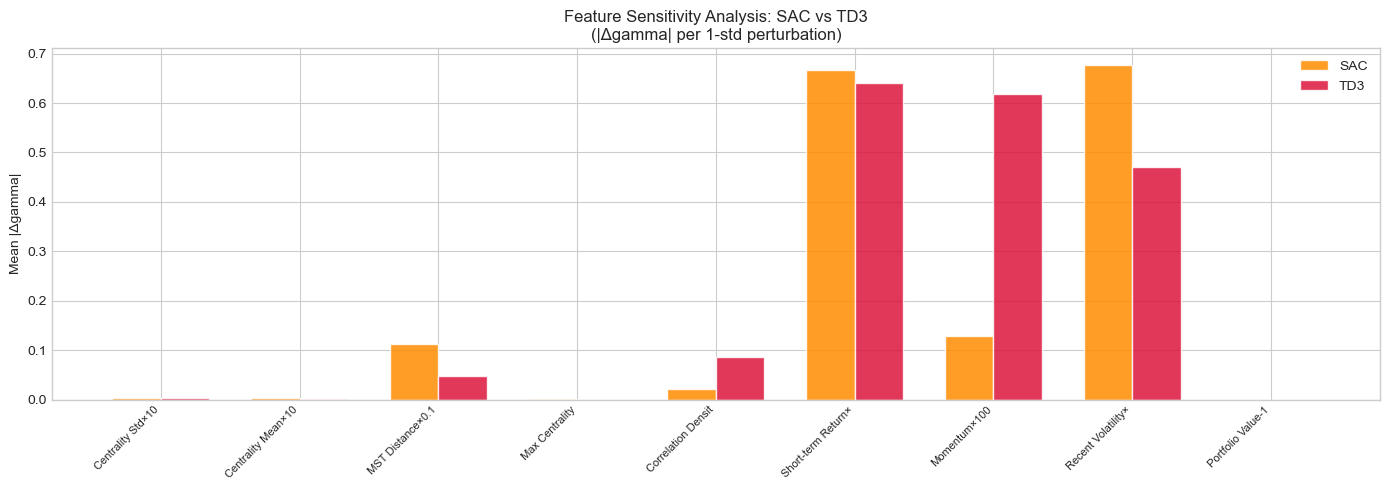

Saved: xai_sensitivity_sac_td3.png


In [28]:
# ── Feature Sensitivity Analysis: SAC vs TD3 ─────────────────────────────
base_obs = xai_obs.mean(axis=0)
perturbation_std = xai_obs.std(axis=0)
n_perturb = 20

sensitivity_sac = np.zeros(len(FEATURE_NAMES))
sensitivity_td3 = np.zeros(len(FEATURE_NAMES))

for feat_idx in range(len(FEATURE_NAMES)):
    diffs_sac, diffs_td3 = [], []
    for _ in range(n_perturb):
        delta = perturbation_std[feat_idx]
        obs_plus  = base_obs.copy(); obs_plus[feat_idx]  += delta
        obs_minus = base_obs.copy(); obs_minus[feat_idx] -= delta

        a_plus_sac,  _ = xai_sac_model.predict(obs_plus.astype(np.float32),  deterministic=True)
        a_minus_sac, _ = xai_sac_model.predict(obs_minus.astype(np.float32), deterministic=True)
        diffs_sac.append(abs(float(a_plus_sac[0]) - float(a_minus_sac[0])))

        a_plus_td3,  _ = xai_td3_model.predict(obs_plus.astype(np.float32),  deterministic=True)
        a_minus_td3, _ = xai_td3_model.predict(obs_minus.astype(np.float32), deterministic=True)
        diffs_td3.append(abs(float(a_plus_td3[0]) - float(a_minus_td3[0])))

    sensitivity_sac[feat_idx] = np.mean(diffs_sac)
    sensitivity_td3[feat_idx] = np.mean(diffs_td3)

# Plot sensitivity comparison
x = np.arange(len(FEATURE_NAMES))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, sensitivity_sac, width, label='SAC',
       color=COLORS['SAC-Net (Sharpe Incr)'], alpha=0.85, edgecolor='white')
ax.bar(x + width/2, sensitivity_td3, width, label='TD3',
       color=COLORS['TD3-Net (Sharpe Incr)'], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f[:18] for f in FEATURE_NAMES], rotation=45, ha='right', fontsize=8)
ax.set_title('Feature Sensitivity Analysis: SAC vs TD3\n(|Δgamma| per 1-std perturbation)')
ax.set_ylabel('Mean |Δgamma|')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(csv_dir, 'xai_sensitivity_sac_td3.png'), dpi=150)
plt.show()
print('Saved: xai_sensitivity_sac_td3.png')

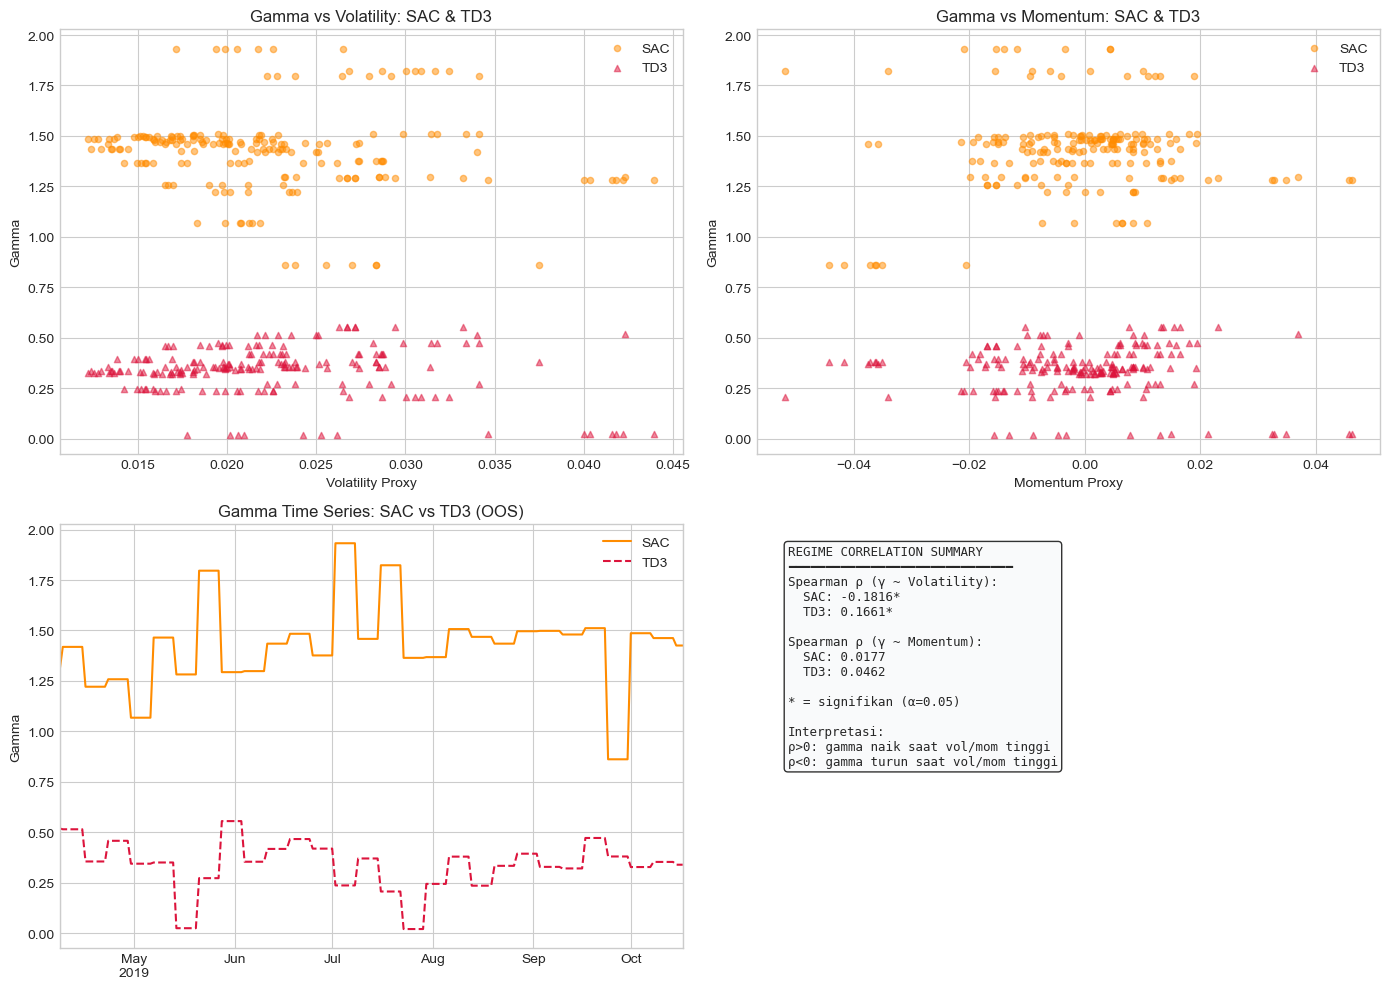

Saved: xai_regime_sac_td3.png


In [29]:
# ── Gamma–Market Regime Correlation: SAC vs TD3 ───────────────────────────
# Ambil gamma dari seed pertama
sac_gamma_series = sac_gamma_test.get('SAC-Net (Sharpe Incr)', None)
td3_gamma_series = td3_gamma_test.get('TD3-Net (Sharpe Incr)', None)

if sac_gamma_series is not None and td3_gamma_series is not None:
    common_idx = sac_gamma_series.index.intersection(td3_gamma_series.index)
    vol_proxy  = ret_test.loc[common_idx].std(axis=1).rolling(7).mean()
    mom_proxy  = ret_test.loc[common_idx].mean(axis=1).rolling(7).mean()

    regime_df = pd.DataFrame({
        'Gamma_SAC': sac_gamma_series.loc[common_idx],
        'Gamma_TD3': td3_gamma_series.loc[common_idx],
        'Volatility': vol_proxy,
        'Momentum'  : mom_proxy,
    }).dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Scatter: gamma vs volatility
    axes[0,0].scatter(regime_df['Volatility'], regime_df['Gamma_SAC'],
                      alpha=0.5, s=20, color=COLORS['SAC-Net (Sharpe Incr)'], label='SAC')
    axes[0,0].scatter(regime_df['Volatility'], regime_df['Gamma_TD3'],
                      alpha=0.5, s=20, color=COLORS['TD3-Net (Sharpe Incr)'], label='TD3', marker='^')
    axes[0,0].set_xlabel('Volatility Proxy')
    axes[0,0].set_ylabel('Gamma')
    axes[0,0].set_title('Gamma vs Volatility: SAC & TD3')
    axes[0,0].legend()

    # Scatter: gamma vs momentum
    axes[0,1].scatter(regime_df['Momentum'], regime_df['Gamma_SAC'],
                      alpha=0.5, s=20, color=COLORS['SAC-Net (Sharpe Incr)'], label='SAC')
    axes[0,1].scatter(regime_df['Momentum'], regime_df['Gamma_TD3'],
                      alpha=0.5, s=20, color=COLORS['TD3-Net (Sharpe Incr)'], label='TD3', marker='^')
    axes[0,1].set_xlabel('Momentum Proxy')
    axes[0,1].set_ylabel('Gamma')
    axes[0,1].set_title('Gamma vs Momentum: SAC & TD3')
    axes[0,1].legend()

    # Time series gamma SAC vs TD3
    regime_df['Gamma_SAC'].plot(ax=axes[1,0], color=COLORS['SAC-Net (Sharpe Incr)'],
                                 label='SAC', linewidth=1.5)
    regime_df['Gamma_TD3'].plot(ax=axes[1,0], color=COLORS['TD3-Net (Sharpe Incr)'],
                                 label='TD3', linewidth=1.5, linestyle='--')
    axes[1,0].set_title('Gamma Time Series: SAC vs TD3 (OOS)')
    axes[1,0].set_ylabel('Gamma')
    axes[1,0].legend()

    # Spearman correlations
    sp_sac_vol, p_sac_vol = stats.spearmanr(regime_df['Gamma_SAC'], regime_df['Volatility'])
    sp_td3_vol, p_td3_vol = stats.spearmanr(regime_df['Gamma_TD3'], regime_df['Volatility'])
    sp_sac_mom, p_sac_mom = stats.spearmanr(regime_df['Gamma_SAC'], regime_df['Momentum'])
    sp_td3_mom, p_td3_mom = stats.spearmanr(regime_df['Gamma_TD3'], regime_df['Momentum'])

    axes[1,1].axis('off')
    summary = (
        f"REGIME CORRELATION SUMMARY\n"
        f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
        f"Spearman ρ (γ ~ Volatility):\n"
        f"  SAC: {sp_sac_vol:.4f}{'*' if p_sac_vol<0.05 else ''}\n"
        f"  TD3: {sp_td3_vol:.4f}{'*' if p_td3_vol<0.05 else ''}\n\n"
        f"Spearman ρ (γ ~ Momentum):\n"
        f"  SAC: {sp_sac_mom:.4f}{'*' if p_sac_mom<0.05 else ''}\n"
        f"  TD3: {sp_td3_mom:.4f}{'*' if p_td3_mom<0.05 else ''}\n\n"
        f"* = signifikan (α=0.05)\n\n"
        f"Interpretasi:\n"
        f"ρ>0: gamma naik saat vol/mom tinggi\n"
        f"ρ<0: gamma turun saat vol/mom tinggi"
    )
    axes[1,1].text(0.05, 0.95, summary, transform=axes[1,1].transAxes,
                   fontsize=9, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

    plt.tight_layout()
    plt.savefig(os.path.join(csv_dir, 'xai_regime_sac_td3.png'), dpi=150)
    plt.show()
    print('Saved: xai_regime_sac_td3.png')
else:
    print('Gamma series tidak tersedia untuk analisis regime.')

## 📋 Catatan untuk Bab Pembahasan Tesis

### Integrasi hasil ke tesis:

| Gambar | Masukkan di | Narasi |
|--------|-------------|--------|
| `insample_cumret_sac_td3.png` | Bab 4, Sub-bab In-Sample | "SAC dan TD3 menunjukkan perbedaan pola kumulatif return..." |
| `gamma_comparison_sac_td3.png` | Bab 4, Sub-bab Analisis Gamma | "Distribusi gamma TD3 lebih/kurang tersebar dibanding SAC..." |
| `oos_cumret_sac_td3.png` | Bab 4, Sub-bab OOS | "Pada periode validasi, SAC/TD3 menunjukkan..." |
| `sac_td3_head2head.png` | Bab 4, Perbandingan Algoritma | "Head-to-head per reward mode menunjukkan..." |
| `sac_td3_metrics_bar.png` | Bab 4, Tabel/Figure Ringkasan | "Secara keseluruhan, X unggul pada metrik Y..." |
| `xai_shap_sac_vs_td3.png` | Bab 4, Sub-bab XAI | "SAC dan TD3 memiliki feature importance yang berbeda..." |
| `xai_sensitivity_sac_td3.png` | Bab 4, Analisis Sensitivitas | "TD3 lebih/kurang sensitif terhadap perubahan volatilitas..." |
| `xai_regime_sac_td3.png` | Bab 4, Market Regime | "Kedua algoritma menunjukkan adaptivitas regime yang..." |

### Limitasi yang perlu dicantumkan:

| # | Limitasi | Dampak |
|---|---------|--------|
| 1 | No Transaction Cost [FIX #6] | Return aktual lebih rendah |
| 2 | Tanh Squashing SAC [FIX #5] | Gamma tidak menyentuh batas ±5 |
| 3 | TD3 action noise σ=0.1 adalah pilihan arbitrary | Sensitivity analysis noise level diperlukan |
| 4 | 3 Seeds saja | Estimasi mean/std terbatas |
| 5 | SHAP KernelExplainer = approximation | Bukan exact Shapley value |

### Poin diskusi SAC vs TD3:
- Jika SAC unggul: entropy regularization membantu eksplorasi di pasar kripto yang volatile
- Jika TD3 unggul: policy deterministik lebih konsisten dan stabil untuk tugas portfolio
- Jika tidak berbeda signifikan (DM test p>0.05): kedua algoritma setara untuk masalah ini

> **Catatan:** Hasil tidak berbeda signifikan bukan berarti penelitian gagal — justru menunjukkan robustness temuan terhadap pilihan algoritma RL.

## 📋 Ringkasan Limitasi Penelitian (untuk Bab Pembahasan)

| # | Limitasi | Dampak | Saran Mitigasi |
|---|---------|--------|----------------|
| 1 | **No Transaction Cost** | Return aktual lebih rendah ~0.05–0.20%/rebalancing | Sebutkan sebagai asumsi; tambahkan sensitivity analysis |
| 2 | **Tanh Squashing SAC** | Gamma tidak pernah menyentuh batas ±5 secara penuh | Jelaskan distribusi gamma efektif di Bab Metodologi |
| 3 | **TD3 Action Noise σ=0.1** | Tingkat eksplorasi TD3 tergantung pilihan noise | Sensitivity analysis terhadap σ ∈ {0.05, 0.1, 0.2} |
| 4 | **3 Seeds saja** | Estimasi mean/std terbatas | Tambah seed jika resources memungkinkan |
| 5 | **Return constraint infeasible** | Saat bearish, fallback ke 1/N | Log jumlah fallback |
| 6 | **SHAP approximation** | KernelExplainer bukan exact Shapley | Sebutkan di limitasi XAI |

> **Catatan:** Limitasi bukan kelemahan fatal — justru menunjukkan kejujuran ilmiah dan membuka peluang penelitian lanjutan.